# Agent Based Simulation of COVID-19 Health and Economical Effects

Prof. Dr. Petrônio Cândido de Lima e Silva <span itemscope itemtype="https://schema.org/Person"><a itemprop="sameAs" content="https://orcid.org/0000-0002-1202-2552" href="https://orcid.org/0000-0002-1202-2552" target="orcid.widget" rel="noopener noreferrer" style="vertical-align:top;"><img src="https://orcid.org/sites/default/files/images/orcid_16x16.png" style="width:1em;margin-right:.5em;" alt="ORCID iD icon"></a></span> (petronio.candido@ifnmg.edu.br)


<img src="https://mirrors.creativecommons.org/presskit/buttons/88x31/svg/by-nc-sa.svg" alt="Creative Commons BY-NC-SA" />

Experiments for the post published on Towards Data Science, available at https://towardsdatascience.com/agent-based-simulation-of-covid-19-health-and-economical-effects-6aa4ae0ff397.


## Installing the package

In [0]:
!pip3 install git+https://github.com/petroniocandido/COVID19_AgentBasedSimulation.git

  Cloning https://github.com/petroniocandido/COVID19_AgentBasedSimulation.git to /tmp/pip-req-build-c9q0zz4o
  Running command git clone -q https://github.com/petroniocandido/COVID19_AgentBasedSimulation.git /tmp/pip-req-build-c9q0zz4o
  Created wheel for covid-abs: filename=covid_abs-0.0.2-cp36-none-any.whl size=30344 sha256=2a44ef5ae1337e0a8b1ae5ff8c2deeb7f5b359fc2ffdf4437a88c9d3caa0fc29
  Stored in directory: /tmp/pip-ephem-wheel-cache-1ogyykn9/wheels/2c/f2/e5/b19523185aa537b4a85e38a764488fbf9f1a0d778647925527
Successfully built covid-abs


## Common imports

In [0]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import animation, rc
from IPython.display import HTML

warnings.simplefilter('ignore')

/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


## Extensions

### 3-6 Add central location

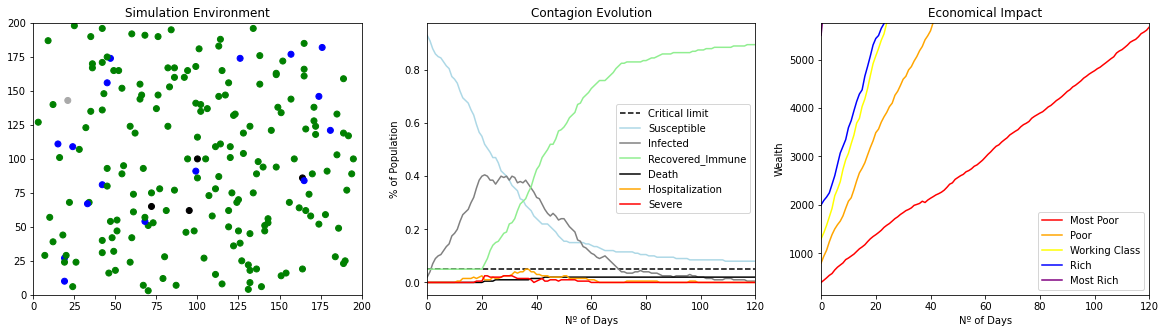

In [0]:
from covid_abs.abs import *
from covid_abs.graphics import *

#normal environment
sim = Simulation(initial_infected_perc = 0.02,
    length=200,                      
    height=200,
    population_size=200,
    contagion_distance=5., 
    contagion_rate=0.9,               
    critical_limit=0.05,
    amplitudes = {                        
        Status.Susceptible : 5, 
        Status.Recovered_Immune : 5, 
        Status.Infected : 5
        }
)

#central location (contagion_rate = 1.5)
env = Simulation(initial_infected_perc = 0.02,
    length=200,                      
    height=200,
    population_size=200,
    contagion_distance=5., 
    contagion_rate=1.5,               
    critical_limit=0.05,
    amplitudes = {                        
        Status.Susceptible : 5, 
        Status.Recovered_Immune : 5, 
        Status.Infected : 5
        }
)

#set the central location as x >= 150, y>=150 in env)
sim.append_trigger_population(lambda a : a.x >= 150 &  a.y >= 150, 
                             'environment', lambda a : env)

sim.append_trigger_population(lambda a : a.x < 150 &  a.y < 150, 
                             'environment', lambda a : sim)

anim = execute_simulation(sim, iterations=120)

#rc('animation', html='jshtml')
rc('animation', html='html5')
anim

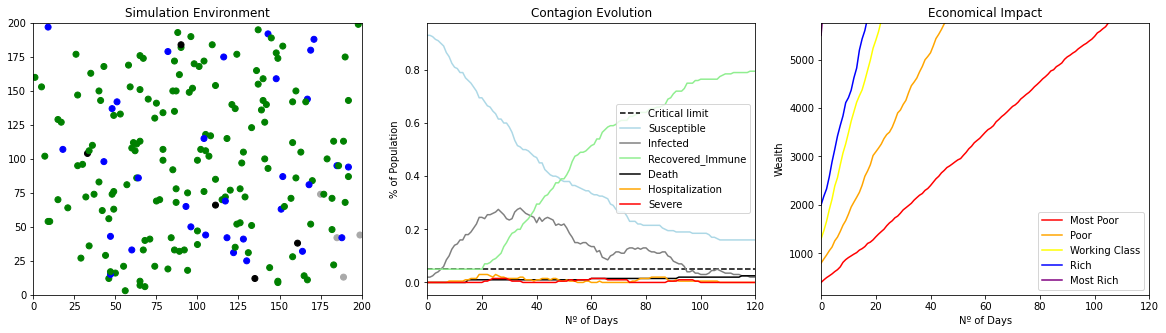

In [0]:
sim = Simulation(initial_infected_perc = 0.02,
    length=200,                      
    height=200,
    population_size=200,
    contagion_distance=5., 
    contagion_rate=0.9,               
    critical_limit=0.05,
    amplitudes = {                        
        Status.Susceptible : 5, 
        Status.Recovered_Immune : 5, 
        Status.Infected : 5
        }
)

anim = execute_simulation(sim, iterations=120)

#rc('animation', html='jshtml')
rc('animation', html='html5')
anim